In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [7]:
df = pd.read_csv("data/row/data.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/row/data.csv'

In [11]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\hardi\OneDrive\Desktop\Disease-Prediction-from-Medical-Data\data\data.csv"
)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [12]:
print("Shape:", df.shape)

df.info()

Shape: (569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter

In [13]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [14]:
df.drop(
    columns=["id", "Unnamed: 32"],
    inplace=True
)

In [15]:


df.isnull().sum()


diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

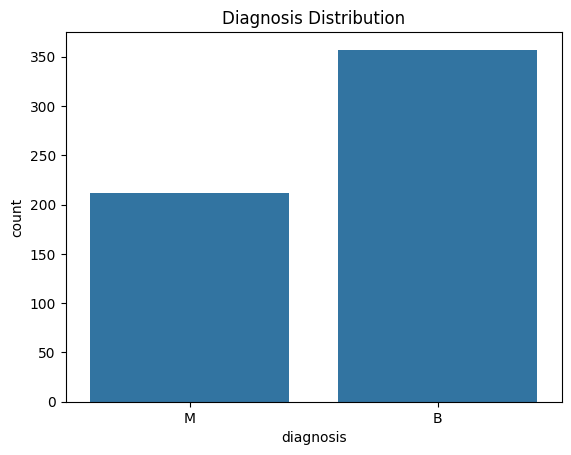

In [16]:
sns.countplot(
    x="diagnosis",
    data=df
)

plt.title("Diagnosis Distribution")
plt.show()

In [17]:
encoder = LabelEncoder()

df["diagnosis"] = encoder.fit_transform(
    df["diagnosis"]
)

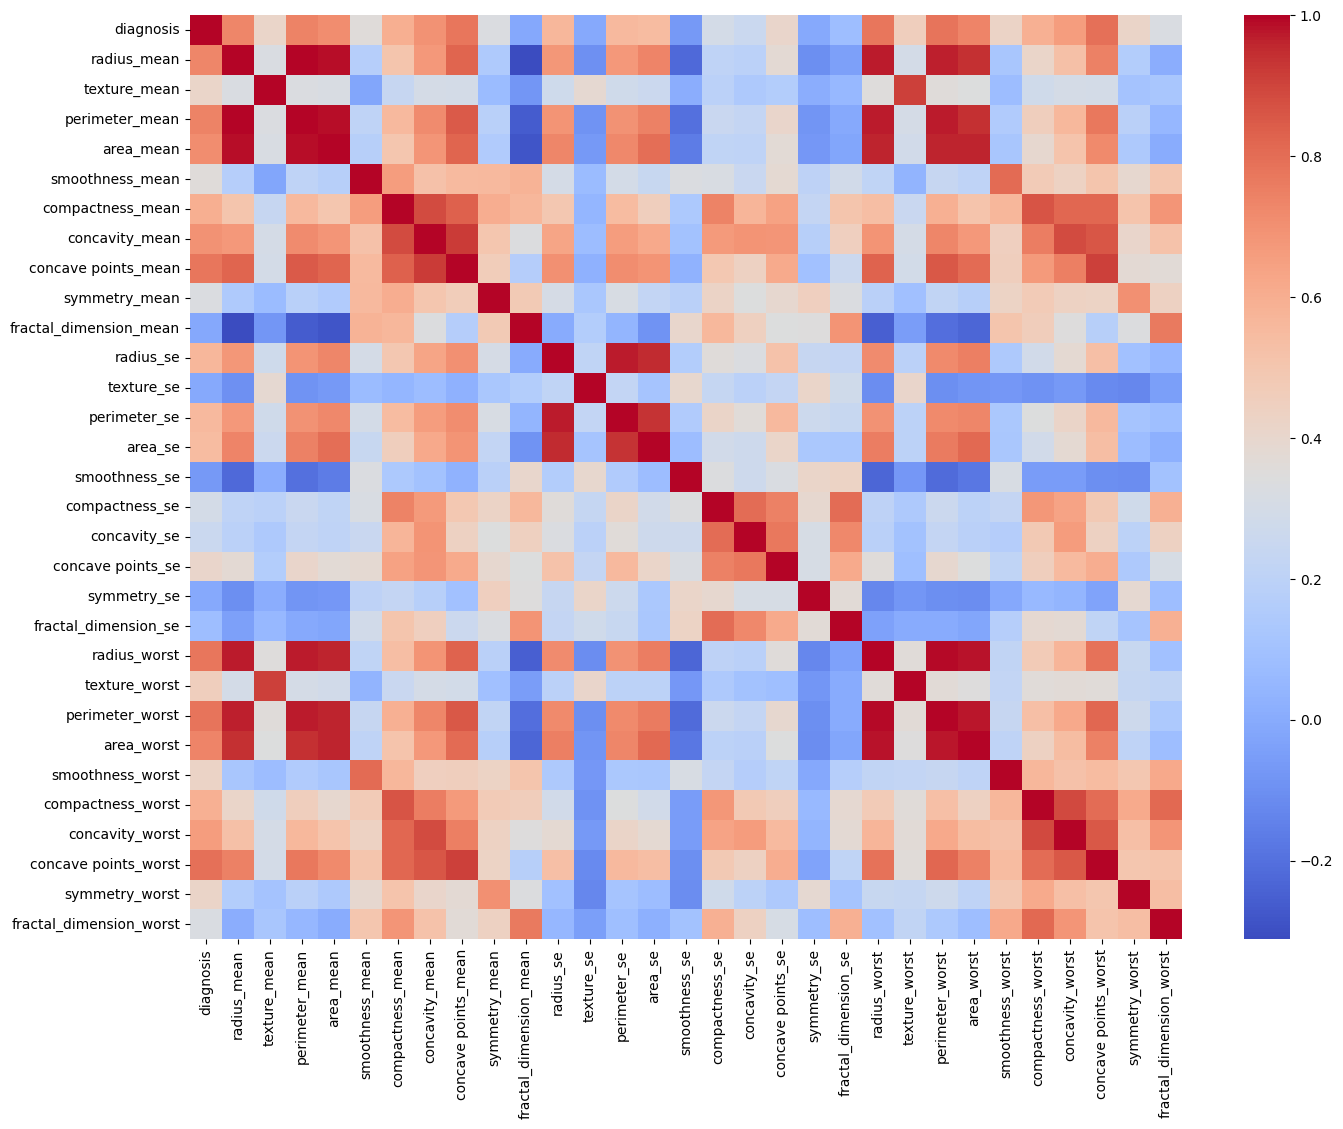

In [18]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

In [19]:
corr = df.corr()

corr["diagnosis"].sort_values(
    ascending=False
)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

In [23]:
X = df.drop(
    "diagnosis",
    axis=1
)

y = df["diagnosis"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [26]:
lr = LogisticRegression()

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

In [27]:
svm = SVC(
    probability=True
)

svm.fit(
    X_train_scaled,
    y_train
)

svm_pred = svm.predict(
    X_test_scaled
)

In [28]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

In [29]:
def evaluate_model(
    y_true,
    y_pred,
    model_name
):

    print("\n", model_name)
    print("=" * 50)

    print(
        "Accuracy:",
        accuracy_score(
            y_true,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred
        )
    )

    print(
        "F1 Score:",
        f1_score(
            y_true,
            y_pred
        )
    )

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

In [30]:
evaluate_model(
    y_test,
    lr_pred,
    "Logistic Regression"
)

evaluate_model(
    y_test,
    svm_pred,
    "SVM"
)

evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)


 Logistic Regression
Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1 Score: 0.9512195121951219
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


 SVM
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
F1 Score: 0.9629629629629629
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


 Random Forest
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
F1 Score: 0.9629629629629629


In [31]:
lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

svm_prob = svm.predict_proba(
    X_test_scaled
)[:,1]

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [32]:
print(
    "LR ROC AUC:",
    roc_auc_score(
        y_test,
        lr_prob
    )
)

print(
    "SVM ROC AUC:",
    roc_auc_score(
        y_test,
        svm_prob
    )
)

print(
    "RF ROC AUC:",
    roc_auc_score(
        y_test,
        rf_prob
    )
)

LR ROC AUC: 0.996031746031746
SVM ROC AUC: 0.9947089947089947
RF ROC AUC: 0.9943783068783069


In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

importance.head(10)

,Feature,Importance
22,perimeter_worst,0.143121
23,area_worst,0.142449
27,concave points_worst,0.112978
7,concave points_mean,0.088663
20,radius_worst,0.082649
0,radius_mean,0.061043
2,perimeter_mean,0.052928
3,area_mean,0.043820
6,concavity_mean,0.039761
13,area_se,0.032237


In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5,
    scoring="f1"
)

grid.fit(
    X_train,
    y_train
)

print(
    grid.best_params_
)

{'max_depth': 15, 'n_estimators': 100}
